In [1]:
# ==============================
# RANDOM FOREST BIAS CORRECTION (FINAL - LOW OVERFITTING + CORRECT EVALUATION)
# ==============================

import os
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------
data_dir = r"C:\Users\geri geri\Desktop\prepicitation riability\TM proposal\data"
excel_file = os.path.join(data_dir, "all chirps vs station.xlsx")

df = pd.read_excel(excel_file)

# --------------------------------------------------
# 2. SORT + STATION STRUCTURE
# --------------------------------------------------
df = df.sort_values("number").reset_index(drop=True)

n_years = 27
samples_per_station = n_years * 12

df["station_id"] = df.index // samples_per_station

# --------------------------------------------------
# 3. FEATURE ENGINEERING
# --------------------------------------------------
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["chirps_lag1"] = df.groupby("station_id")["chirps_precip"].shift(1)
df["chirps_lag12"] = df.groupby("station_id")["chirps_precip"].shift(12)

df = df.dropna().reset_index(drop=True)

# --------------------------------------------------
# 4. FEATURES / TARGET
# --------------------------------------------------
features = [
    "chirps_precip",
    "month_sin",
    "month_cos",
    "chirps_lag1",
    "chirps_lag12"
]

X = df[features]
y = df["station_precip"]

# --------------------------------------------------
# 5. TRAIN / TEST SPLIT (TIME-BASED)
# --------------------------------------------------
train_size = 22 * 12

train_list = []
test_list = []

for sid in df["station_id"].unique():
    station_df = df[df["station_id"] == sid]
    
    train_list.append(station_df.iloc[:train_size])
    test_list.append(station_df.iloc[train_size:])

df_train = pd.concat(train_list)
df_test = pd.concat(test_list)

X_train = df_train[features]
y_train = df_train["station_precip"]

X_test = df_test[features]
y_test = df_test["station_precip"]

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))

# --------------------------------------------------
# 6. MODEL (RANDOM FOREST - CONTROLLED)
# --------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

pipeline = Pipeline([
    ("rf", RandomForestRegressor(random_state=42))
])

# 🔥 Anti-overfitting settings
param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [5, 8, 10],          # limit tree depth
    "rf__min_samples_split": [10, 20],
    "rf__min_samples_leaf": [5, 10],      # prevents memorization
    "rf__max_features": ["sqrt", 0.7]     # reduce feature dominance
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("\nBEST PARAMETERS:")
print(grid.best_params_)

# --------------------------------------------------
# 7. BIAS CORRECTION
# --------------------------------------------------
df_test["corrected_chirps"] = np.clip(best_rf.predict(X_test), 0, None)

# --------------------------------------------------
# 8. DRY DAY CORRECTION
# --------------------------------------------------
df_test["corrected_chirps"] = np.where(
    df_test["chirps_precip"] < 1,
    0,
    df_test["corrected_chirps"]
)

# --------------------------------------------------
# 9. PERFORMANCE COMPARISON
# --------------------------------------------------

print("\n===== BEFORE CORRECTION (RAW CHIRPS) =====")
print("R²   :", r2_score(y_test, df_test["chirps_precip"]))
print("RMSE :", np.sqrt(mean_squared_error(y_test, df_test["chirps_precip"])))
print("MAE  :", mean_absolute_error(y_test, df_test["chirps_precip"]))

print("\n===== AFTER CORRECTION (RANDOM FOREST) =====")
print("R²   :", r2_score(y_test, df_test["corrected_chirps"]))
print("RMSE :", np.sqrt(mean_squared_error(y_test, df_test["corrected_chirps"])))
print("MAE  :", mean_absolute_error(y_test, df_test["corrected_chirps"]))

# --------------------------------------------------
# 10. OUTPUT DATASET
# --------------------------------------------------
output = df_test[[
    "station_precip",
    "chirps_precip",
    "corrected_chirps",
    "month",
    "station_id"
]]

print("\nSample Output:")
print(output.head())

Train samples: 2376
Test samples : 432
Fitting 5 folds for each of 48 candidates, totalling 240 fits

BEST PARAMETERS:
{'rf__max_depth': 5, 'rf__max_features': 0.7, 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 20, 'rf__n_estimators': 200}

===== BEFORE CORRECTION (RAW CHIRPS) =====
R²   : 0.6465885129710138
RMSE : 76.86146332173362
MAE  : 43.85764883603704

===== AFTER CORRECTION (RANDOM FOREST) =====
R²   : 0.7136922958451073
RMSE : 69.18068135432682
MAE  : 40.810060317752466

Sample Output:
     station_precip  chirps_precip  corrected_chirps  month  station_id
264             0.0       0.000000          0.000000      1           0
265             0.0       0.000000          0.000000      2           0
266             1.0      14.368457         17.110035      3           0
267            32.7      51.751168         50.271682      4           0
268           207.9     149.010549        173.204332      5           0


In [2]:
# ==============================
# SVM (SVR) BIAS CORRECTION (FINAL - LOW OVERFITTING + CORRECT EVALUATION)
# ==============================

import os
import numpy as np
import pandas as pd

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------
data_dir = r"C:\Users\geri geri\Desktop\prepicitation riability\TM proposal\data"
excel_file = os.path.join(data_dir, "all chirps vs station.xlsx")

df = pd.read_excel(excel_file)

# --------------------------------------------------
# 2. SORT + STATION STRUCTURE
# --------------------------------------------------
df = df.sort_values("number").reset_index(drop=True)

n_years = 27
samples_per_station = n_years * 12

df["station_id"] = df.index // samples_per_station

# --------------------------------------------------
# 3. FEATURE ENGINEERING
# --------------------------------------------------
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["chirps_lag1"] = df.groupby("station_id")["chirps_precip"].shift(1)
df["chirps_lag12"] = df.groupby("station_id")["chirps_precip"].shift(12)

df = df.dropna().reset_index(drop=True)

# --------------------------------------------------
# 4. FEATURES / TARGET
# --------------------------------------------------
features = [
    "chirps_precip",
    "month_sin",
    "month_cos",
    "chirps_lag1",
    "chirps_lag12"
]

X = df[features]
y = df["station_precip"]

# --------------------------------------------------
# 5. TRAIN / TEST SPLIT (TIME-BASED)
# --------------------------------------------------
train_size = 22 * 12

train_list = []
test_list = []

for sid in df["station_id"].unique():
    station_df = df[df["station_id"] == sid]
    
    train_list.append(station_df.iloc[:train_size])
    test_list.append(station_df.iloc[train_size:])

df_train = pd.concat(train_list)
df_test = pd.concat(test_list)

X_train = df_train[features]
y_train = df_train["station_precip"]

X_test = df_test[features]
y_test = df_test["station_precip"]

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))

# --------------------------------------------------
# 6. MODEL (SVR - REGULARIZED)
# --------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

# 🔥 Anti-overfitting SVM settings
param_grid = {
    "svr__kernel": ["rbf"],
    "svr__C": [0.1, 1, 5],          # lower C → smoother
    "svr__epsilon": [0.3, 0.5, 1.0], # tolerance → smoother predictions
    "svr__gamma": [0.01, 0.05, "scale"]  # restrict flexibility
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_svr = grid.best_estimator_

print("\nBEST PARAMETERS:")
print(grid.best_params_)

# --------------------------------------------------
# 7. BIAS CORRECTION
# --------------------------------------------------
df_test["corrected_chirps"] = np.clip(best_svr.predict(X_test), 0, None)

# --------------------------------------------------
# 8. DRY DAY CORRECTION
# --------------------------------------------------
df_test["corrected_chirps"] = np.where(
    df_test["chirps_precip"] < 1,
    0,
    df_test["corrected_chirps"]
)

# --------------------------------------------------
# 9. PERFORMANCE COMPARISON
# --------------------------------------------------

print("\n===== BEFORE CORRECTION (RAW CHIRPS) =====")
print("R²   :", r2_score(y_test, df_test["chirps_precip"]))
print("RMSE :", np.sqrt(mean_squared_error(y_test, df_test["chirps_precip"])))
print("MAE  :", mean_absolute_error(y_test, df_test["chirps_precip"]))

print("\n===== AFTER CORRECTION (SVM) =====")
print("R²   :", r2_score(y_test, df_test["corrected_chirps"]))
print("RMSE :", np.sqrt(mean_squared_error(y_test, df_test["corrected_chirps"])))
print("MAE  :", mean_absolute_error(y_test, df_test["corrected_chirps"]))

# --------------------------------------------------
# 10. OUTPUT DATASET
# --------------------------------------------------
output = df_test[[
    "station_precip",
    "chirps_precip",
    "corrected_chirps",
    "month",
    "station_id"
]]

print("\nSample Output:")
print(output.head())

Train samples: 2376
Test samples : 432
Fitting 5 folds for each of 27 candidates, totalling 135 fits

BEST PARAMETERS:
{'svr__C': 5, 'svr__epsilon': 0.3, 'svr__gamma': 0.05, 'svr__kernel': 'rbf'}

===== BEFORE CORRECTION (RAW CHIRPS) =====
R²   : 0.6465885129710138
RMSE : 76.86146332173362
MAE  : 43.85764883603704

===== AFTER CORRECTION (SVM) =====
R²   : 0.7350246896975408
RMSE : 66.55351882808836
MAE  : 39.355866534292176

Sample Output:
     station_precip  chirps_precip  corrected_chirps  month  station_id
264             0.0       0.000000          0.000000      1           0
265             0.0       0.000000          0.000000      2           0
266             1.0      14.368457         17.015418      3           0
267            32.7      51.751168         46.289276      4           0
268           207.9     149.010549        153.009323      5           0


In [3]:
# ==============================
# XGBOOST BIAS CORRECTION (FINAL - LOW OVERFITTING + CORRECT EVALUATION)
# ==============================

import os
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------
data_dir = r"C:\Users\geri geri\Desktop\prepicitation riability\TM proposal\data"
excel_file = os.path.join(data_dir, "all chirps vs station.xlsx")

df = pd.read_excel(excel_file)

# --------------------------------------------------
# 2. SORT + STATION STRUCTURE
# --------------------------------------------------
df = df.sort_values("number").reset_index(drop=True)

n_years = 27
samples_per_station = n_years * 12

df["station_id"] = df.index // samples_per_station

# --------------------------------------------------
# 3. FEATURE ENGINEERING
# --------------------------------------------------
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["chirps_lag1"] = df.groupby("station_id")["chirps_precip"].shift(1)
df["chirps_lag12"] = df.groupby("station_id")["chirps_precip"].shift(12)

df = df.dropna().reset_index(drop=True)

# --------------------------------------------------
# 4. FEATURES / TARGET
# --------------------------------------------------
features = [
    "chirps_precip",
    "month_sin",
    "month_cos",
    "chirps_lag1",
    "chirps_lag12"
]

X = df[features]
y = df["station_precip"]

# --------------------------------------------------
# 5. TRAIN / TEST SPLIT (TIME-BASED)
# --------------------------------------------------
train_size = 22 * 12

train_list = []
test_list = []

for sid in df["station_id"].unique():
    station_df = df[df["station_id"] == sid]
    
    train_list.append(station_df.iloc[:train_size])
    test_list.append(station_df.iloc[train_size:])

df_train = pd.concat(train_list)
df_test = pd.concat(test_list)

X_train = df_train[features]
y_train = df_train["station_precip"]

X_test = df_test[features]
y_test = df_test["station_precip"]

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))

# --------------------------------------------------
# 6. MODEL (XGBOOST - REGULARIZED)
# --------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# 🔥 Strong anti-overfitting grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],              # shallow trees = less overfit
    "learning_rate": [0.01, 0.05, 0.1],  # slow learning = stable
    "subsample": [0.7, 0.8],             # row sampling
    "colsample_bytree": [0.7, 0.8],      # feature sampling
    "min_child_weight": [3, 5, 10]       # regularization
}

grid = GridSearchCV(
    xgb,
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_

print("\nBEST PARAMETERS:")
print(grid.best_params_)

# --------------------------------------------------
# 7. BIAS CORRECTION
# --------------------------------------------------
df_test["corrected_chirps"] = np.clip(best_xgb.predict(X_test), 0, None)

# --------------------------------------------------
# 8. DRY DAY CORRECTION
# --------------------------------------------------
df_test["corrected_chirps"] = np.where(
    df_test["chirps_precip"] < 1,
    0,
    df_test["corrected_chirps"]
)

# --------------------------------------------------
# 9. PERFORMANCE COMPARISON
# --------------------------------------------------

print("\n===== BEFORE CORRECTION (RAW CHIRPS) =====")
print("R²   :", r2_score(y_test, df_test["chirps_precip"]))
print("RMSE :", np.sqrt(mean_squared_error(y_test, df_test["chirps_precip"])))
print("MAE  :", mean_absolute_error(y_test, df_test["chirps_precip"]))

print("\n===== AFTER CORRECTION (XGBOOST) =====")
print("R²   :", r2_score(y_test, df_test["corrected_chirps"]))
print("RMSE :", np.sqrt(mean_squared_error(y_test, df_test["corrected_chirps"])))
print("MAE  :", mean_absolute_error(y_test, df_test["corrected_chirps"]))

# --------------------------------------------------
# 10. OUTPUT DATASET
# --------------------------------------------------
output = df_test[[
    "station_precip",
    "chirps_precip",
    "corrected_chirps",
    "month",
    "station_id"
]]

print("\nSample Output:")
print(output.head())

Train samples: 2376
Test samples : 432
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

BEST PARAMETERS:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 100, 'subsample': 0.8}

===== BEFORE CORRECTION (RAW CHIRPS) =====
R²   : 0.6465885129710138
RMSE : 76.86146332173362
MAE  : 43.85764883603704

===== AFTER CORRECTION (XGBOOST) =====
R²   : 0.7131101534930506
RMSE : 69.25097732128265
MAE  : 40.68344593246778

Sample Output:
     station_precip  chirps_precip  corrected_chirps  month  station_id
264             0.0       0.000000          0.000000      1           0
265             0.0       0.000000          0.000000      2           0
266             1.0      14.368457         19.922449      3           0
267            32.7      51.751168         47.196171      4           0
268           207.9     149.010549        174.789062      5           0


In [4]:
# ==============================
# KNN BIAS CORRECTION (FINAL - LOW OVERFITTING + CORRECT EVALUATION)
# ==============================

import os
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------
data_dir = r"C:\Users\geri geri\Desktop\prepicitation riability\TM proposal\data"
excel_file = os.path.join(data_dir, "all chirps vs station.xlsx")

df = pd.read_excel(excel_file)

# --------------------------------------------------
# 2. SORT + STATION STRUCTURE
# --------------------------------------------------
df = df.sort_values("number").reset_index(drop=True)

n_years = 27
samples_per_station = n_years * 12

df["station_id"] = df.index // samples_per_station

# --------------------------------------------------
# 3. FEATURE ENGINEERING
# --------------------------------------------------
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["chirps_lag1"] = df.groupby("station_id")["chirps_precip"].shift(1)
df["chirps_lag12"] = df.groupby("station_id")["chirps_precip"].shift(12)

df = df.dropna().reset_index(drop=True)

# --------------------------------------------------
# 4. FEATURES / TARGET
# --------------------------------------------------
features = [
    "chirps_precip",
    "month_sin",
    "month_cos",
    "chirps_lag1",
    "chirps_lag12"
]

X = df[features]
y = df["station_precip"]

# --------------------------------------------------
# 5. TRAIN / TEST SPLIT (TIME-BASED)
# --------------------------------------------------
train_size = 22 * 12

train_list = []
test_list = []

for sid in df["station_id"].unique():
    station_df = df[df["station_id"] == sid]
    
    train_list.append(station_df.iloc[:train_size])
    test_list.append(station_df.iloc[train_size:])

df_train = pd.concat(train_list)
df_test = pd.concat(test_list)

X_train = df_train[features]
y_train = df_train["station_precip"]

X_test = df_test[features]
y_test = df_test["station_precip"]

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))

# --------------------------------------------------
# 6. MODEL (LOW-FIT KNN)
# --------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor())
])

# 🔥 Large K → smoother → less overfitting
param_grid = {
    "knn__n_neighbors": [25, 50, 75, 100],
    "knn__weights": ["uniform"],
    "knn__p": [2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_knn = grid.best_estimator_

print("\nBEST PARAMETERS:")
print(grid.best_params_)

# --------------------------------------------------
# 7. BIAS CORRECTION (PREDICTION)
# --------------------------------------------------

df_test["corrected_chirps"] = np.clip(best_knn.predict(X_test), 0, None)

# --------------------------------------------------
# 🔥 8. DRY DAY CORRECTION (VERY IMPORTANT)
# --------------------------------------------------
df_test["corrected_chirps"] = np.where(
    df_test["chirps_precip"] < 1,
    0,
    df_test["corrected_chirps"]
)

# --------------------------------------------------
# 9. PERFORMANCE COMPARISON
# --------------------------------------------------

print("\n===== BEFORE CORRECTION (RAW CHIRPS) =====")
print("R²   :", r2_score(y_test, df_test["chirps_precip"]))
print("RMSE :", np.sqrt(mean_squared_error(y_test, df_test["chirps_precip"])))
print("MAE  :", mean_absolute_error(y_test, df_test["chirps_precip"]))

print("\n===== AFTER CORRECTION (KNN) =====")
print("R²   :", r2_score(y_test, df_test["corrected_chirps"]))
print("RMSE :", np.sqrt(mean_squared_error(y_test, df_test["corrected_chirps"])))
print("MAE  :", mean_absolute_error(y_test, df_test["corrected_chirps"]))

# --------------------------------------------------
# 10. OUTPUT DATASET
# --------------------------------------------------
output = df_test[[
    "station_precip",
    "chirps_precip",
    "corrected_chirps",
    "month",
    "station_id"
]]

print("\nSample Output:")
print(output.head())

Train samples: 2376
Test samples : 432
Fitting 5 folds for each of 4 candidates, totalling 20 fits

BEST PARAMETERS:
{'knn__n_neighbors': 25, 'knn__p': 2, 'knn__weights': 'uniform'}

===== BEFORE CORRECTION (RAW CHIRPS) =====
R²   : 0.6465885129710138
RMSE : 76.86146332173362
MAE  : 43.85764883603704

===== AFTER CORRECTION (KNN) =====
R²   : 0.7087937452169936
RMSE : 69.76999104650673
MAE  : 40.941435185185185

Sample Output:
     station_precip  chirps_precip  corrected_chirps  month  station_id
264             0.0       0.000000             0.000      1           0
265             0.0       0.000000             0.000      2           0
266             1.0      14.368457            29.312      3           0
267            32.7      51.751168            60.316      4           0
268           207.9     149.010549           152.704      5           0


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

In [6]:
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    bias = np.mean(y_pred - y_true)
    
    return rmse, mae, r2, corr, bias

In [8]:
# Raw CHIRPS (baseline)
chirps_test = df_test["chirps_precip"].values

# KNN prediction
knn_pred = best_knn.predict(X_test)

# Random Forest prediction
rf_pred = best_rf.predict(X_test)

# SVM prediction
svm_pred = best_svr.predict(X_test)

# XGBoost prediction
xgb_pred = best_xgb.predict(X_test)

In [12]:
results = {}

# Raw CHIRPS ONLY for evaluation (NOT plotting)
chirps_metrics = compute_metrics(
    y_test,
    df_test["chirps_precip"].values
)

# ML models only
results["KNN"] = compute_metrics(y_test, knn_pred)
results["Random Forest"] = compute_metrics(y_test, rf_pred)
results["SVM"] = compute_metrics(y_test, svm_pred)
results["XGBoost"] = compute_metrics(y_test, xgb_pred)

metrics_df = pd.DataFrame(results, index=[
    "RMSE",
    "MAE",
    "R2",
    "Correlation",
    "Bias"
])

print(metrics_df)

                   KNN  Random Forest        SVM    XGBoost
RMSE         69.770317      69.162282  66.546802  69.245678
MAE          41.099102      40.899298  39.394341  40.923922
R2            0.708791       0.713845   0.735078   0.713154
Correlation   0.846732       0.849422   0.859627   0.848689
Bias         -1.152398       1.695326  -6.908233   0.950860


### plot heatmap

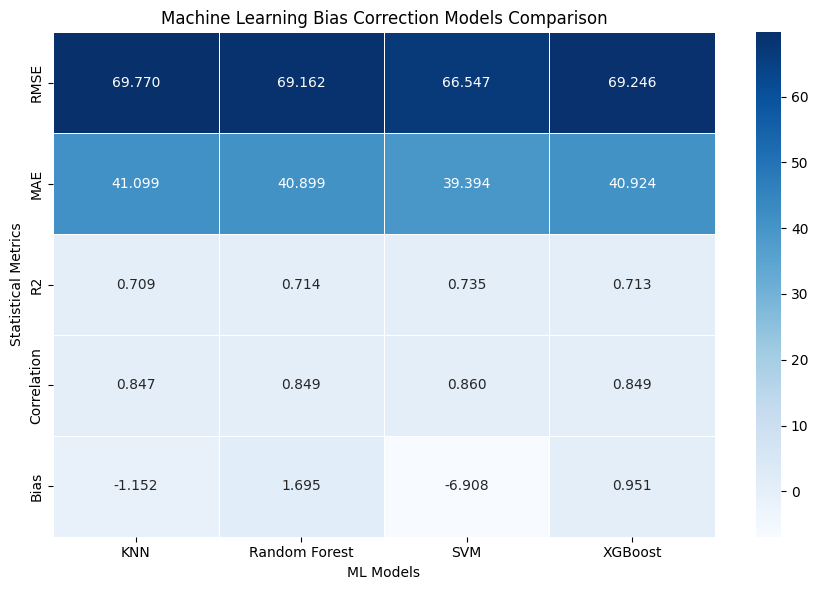

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

sns.heatmap(
    metrics_df,
    annot=True,
    cmap="Blues",
    linewidths=0.5,
    fmt=".3f"
)

plt.title("Machine Learning Bias Correction Models Comparison")
plt.xlabel("ML Models")
plt.ylabel("Statistical Metrics")

plt.tight_layout()
plt.show()

### Ranking ML models

In [14]:
import numpy as np
import pandas as pd

df = metrics_df.copy()

# -----------------------------
# 1. Convert all metrics so "higher = better"
# -----------------------------

# R2 (already good → keep as is)
df.loc["R2"] = df.loc["R2"]

# Correlation (already good)
df.loc["Correlation"] = df.loc["Correlation"]

# RMSE (lower is better → invert)
df.loc["RMSE"] = -df.loc["RMSE"]

# MAE (lower is better → invert)
df.loc["MAE"] = -df.loc["MAE"]

# Bias (closer to 0 is better → penalize absolute bias)
df.loc["Bias"] = -np.abs(df.loc["Bias"])

# -----------------------------
# 2. Compute final score
# -----------------------------
model_score = df.mean(axis=0)

# -----------------------------
# 3. Rank models
# -----------------------------
ranking = model_score.sort_values(ascending=False)

print("\n🏆 MODEL RANKING:")
print(ranking)


🏆 MODEL RANKING:
XGBoost         -21.911723
Random Forest   -22.038728
KNN             -22.093259
SVM             -22.250934
dtype: float64
